Лабораторна робота №3
Тема: візуалізація даних.
Виконала: Александрова Маргарита, студентка групи ФБ-41

1. Обрати унікальний датасет, який відповідає зазначеним вимогам.

Я обрала датасет Chronic Kidney Disease, який містить медичні дані пацієнтів і використовується для визначення наявності хронічної хвороби нирок. Він включає 400 записів та 24 ознаки, серед яких є як числові (наприклад, вік та артеріальний тиск), так і категоріальні (рівень білка, наявність симптомів тощо).
Він включає як числові, так і категоріальні ознаки, а також містить пропущені значення.

Тепер завантажую датасет. 
У моєму віртуальному середовищі вже встановлена бібліотека ucimirepo, яка знадобиться для завантаження.

In [8]:
from ucimlrepo import fetch_ucirepo
# завантаження датасету
chronic_kidney_disease = fetch_ucirepo(id=336)

# отримання даних
X = chronic_kidney_disease.data.features
y = chronic_kidney_disease.data.targets

# переглядаємо дані
X.head()
y.head()

,class
0,ckd
1,ckd
2,ckd
3,ckd
4,ckd


In [9]:
import pandas as pd

# об'єднуємо все в один датафрейм

df = pd.concat([X, y], axis=1)
df.head()

,age,bp,sg,al,su,rbc,pc,pcc,ba,bgr,...,pcv,wbcc,rbcc,htn,dm,cad,appet,pe,ane,class
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44.0,7800.0,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38.0,6000.0,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31.0,7500.0,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32.0,6700.0,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35.0,7300.0,4.6,no,no,no,good,no,no,ckd


In [10]:
# переглянемо дані
df.info()
df.isna().sum()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     391 non-null    float64
 1   bp      388 non-null    float64
 2   sg      353 non-null    float64
 3   al      354 non-null    float64
 4   su      351 non-null    float64
 5   rbc     248 non-null    str    
 6   pc      335 non-null    str    
 7   pcc     396 non-null    str    
 8   ba      396 non-null    str    
 9   bgr     356 non-null    float64
 10  bu      381 non-null    float64
 11  sc      383 non-null    float64
 12  sod     313 non-null    float64
 13  pot     312 non-null    float64
 14  hemo    348 non-null    float64
 15  pcv     329 non-null    float64
 16  wbcc    294 non-null    float64
 17  rbcc    269 non-null    float64
 18  htn     398 non-null    str    
 19  dm      398 non-null    str    
 20  cad     398 non-null    str    
 21  appet   399 non-null    str    
 22  pe      399 n

age        9
bp        12
sg        47
al        46
su        49
rbc      152
pc        65
pcc        4
ba         4
bgr       44
bu        19
sc        17
sod       87
pot       88
hemo      52
pcv       71
wbcc     106
rbcc     131
htn        2
dm         2
cad        2
appet      1
pe         1
ane        1
class      0
dtype: int64

Датасет містить 400 записів і 25 атрибутів різних типів: числові та категоріальні. У деяких колонках присутні пропущені значення, що підтверджується різницею між загальною кількістю записів і значеннями Non-Null Count.

2. Здійснити Data Cleaning.

In [11]:
# очищаємо від кривих значень
df = df.replace("?", pd.NA)
df = df.replace(" ?", pd.NA)
df = df.replace("\t?", pd.NA)

# перетворюємо типи даних
numeric_cols = ["age", "bp", "sg", "al", "su", "bgr", "bu", "sc", "sod", "pot", "hemo", "pcv", "wbcc", "rbcc"]

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors="coerce")

# обробляємо категоріальні значення
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)

# заповнюємо пропуски
# 1. числові - медіана
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

# 2. категоріальні - "Unknown"
categorical_cols = df.select_dtypes(include="object").columns
df[categorical_cols] = df[categorical_cols].fillna("Unknown")

# перевіряємо після очистки
df.isna().sum()

/var/folders/t5/j8qn3z3936s1p2ky5q46vpfc0000gn/T/ipykernel_34018/2258565055.py:20: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include="object").columns


age      0
bp       0
sg       0
al       0
su       0
rbc      0
pc       0
pcc      0
ba       0
bgr      0
bu       0
sc       0
sod      0
pot      0
hemo     0
pcv      0
wbcc     0
rbcc     0
htn      0
dm       0
cad      0
appet    0
pe       0
ane      0
class    0
dtype: int64

У процесі очищення для числових змінних пропуски були заповнені медіанними значеннями, що дозволяє зменшити вплив викидів. Для категоріальних змінних пропущені значення були замінені на окрему категорію "Unknown". Після обробки було виконано перевірку, яка показала відсутність пропущених значень у датасеті.

3. Побудувати графіки залежності одного integer/real атрибута від іншого.

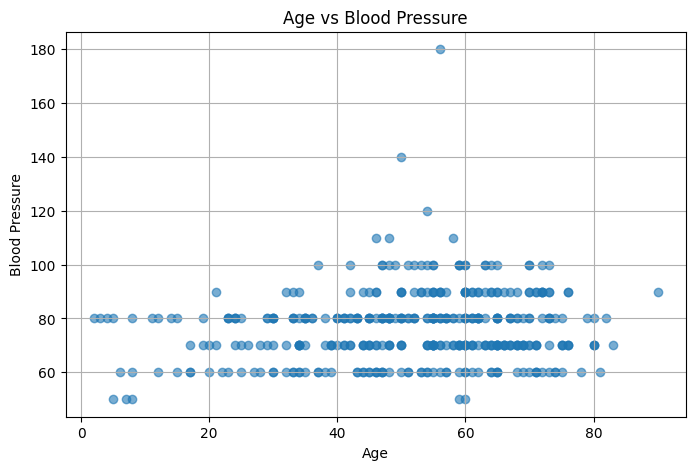

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5)) # створюємо фігуру заданого розміру
plt.scatter(df["age"], df["bp"], alpha=0.6) # значення по осі х та у
plt.xlabel("Age")
plt.ylabel("Blood Pressure")
plt.title("Age vs Blood Pressure")
plt.grid(True) # додавання сітки
plt.show()

Діаграма розсіювання показує залежність між віком пацієнтів та артеріальним тиском. Більшість значень тиску знаходиться в межах 60–100 незалежно від віку. Явної сильної залежності між віком і тиском не спостерігається, хоча у старших пацієнтів іноді зустрічаються вищі значення тиску. Також можна помітити окремі викиди (наприклад, значення близько 180).

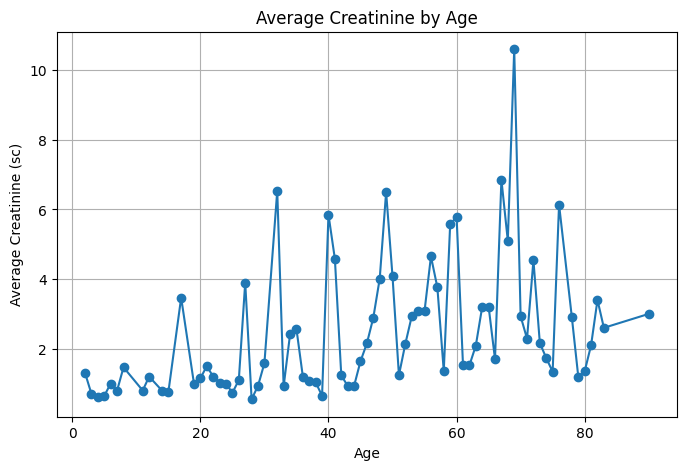

In [19]:
df_grouped = df.groupby("age")["sc"].mean().reset_index() # групуємо дані за віком

plt.figure(figsize=(8,5))
plt.plot(df_grouped["age"], df_grouped["sc"], marker='o') # будуємо лінійний графік
plt.xlabel("Age")
plt.ylabel("Average Creatinine (sc)")
plt.title("Average Creatinine by Age")
plt.grid(True)
plt.show()

Було побудовано лінійний графік середнього значення рівня креатиніну залежно від віку пацієнтів. Для цього дані було згруповано за віком, після чого обчислено середнє значення показника для кожної вікової групи.
З графіка видно, що рівень креатиніну має тенденцію до збільшення з віком, хоча спостерігаються значні коливання. Також можна помітити окремі пікові значення, які можуть свідчити про наявність викидів або індивідуальних особливостей пацієнтів.

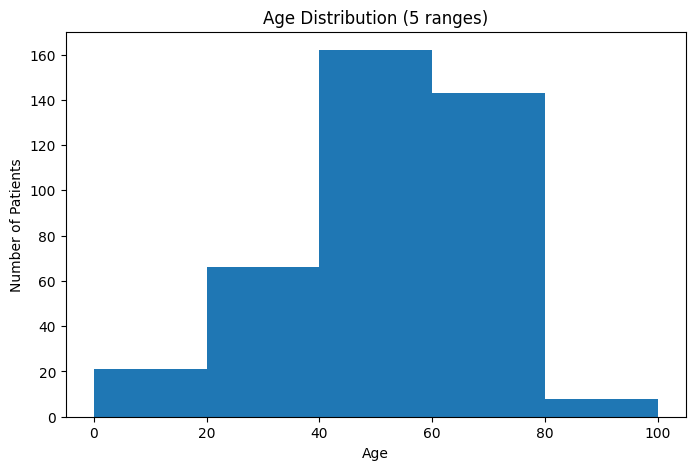

In [20]:
import matplotlib.pyplot as plt

bins = [0, 20, 40, 60, 80, 100] # визначаємо діапазони вручну

plt.figure(figsize=(8,5))
plt.hist(df["age"], bins=bins) # будуємо гістограму
plt.xlabel("Age")
plt.ylabel("Number of Patients")
plt.title("Age Distribution (5 ranges)")
plt.show()

Було побудовано гістограму розподілу віку пацієнтів. Для аналізу було задано 5 діапазонів значень: 0–20, 20–40, 40–60, 60–80 та 80–100 років.
Гістограма показує кількість пацієнтів у кожному віковому інтервалі. Найбільша кількість спостережень припадає на діапазони 40–60 та 60–80 років, що свідчить про переважання пацієнтів середнього та старшого віку у вибірці. Найменша кількість спостережень — у крайніх діапазонах (0–20 та 80–100 років).

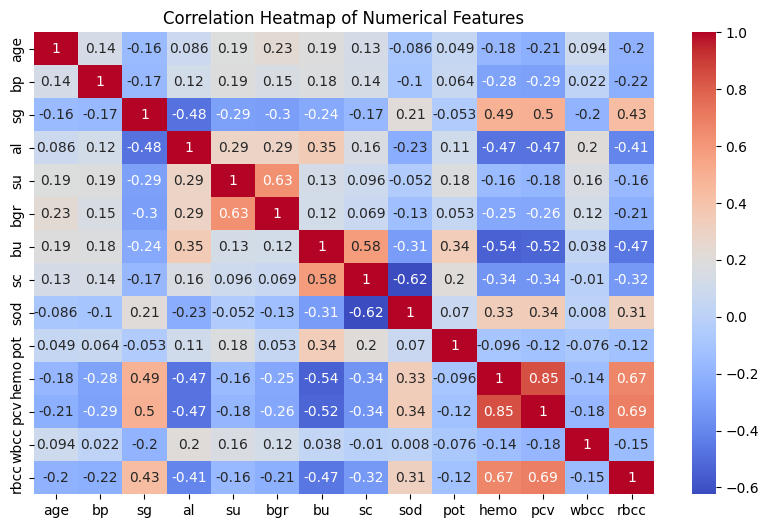

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

# обчислюємо кореляційну матрицю для числових ознак
# numeric_only=True — враховуються тільки числові змінні
# annot=True — відображає значення кореляцій на графіку
# cmap="coolwarm" — кольорова схема (сині - негативні, червоні - позитивні)
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

Було побудовано теплову карту кореляцій між числовими ознаками датасету. Графік дозволяє візуально оцінити силу та напрямок зв’язку між змінними.
Найбільш сильна пряма кореляція спостерігається між показниками гемоглобіну (hemo) та об’єму еритроцитів (pcv), а також між pcv та кількістю еритроцитів (rbcc). Це свідчить про тісний зв’язок між цими медичними показниками.
Також можна помітити від’ємну кореляцію між деякими змінними, наприклад між рівнем альбуміну (al) та гемоглобіном (hemo). Більшість інших змінних мають слабку або помірну кореляцію.

/Users/margarita/зпад/venv/lib/python3.13/site-packages/seaborn/utils.py:61: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.draw()


/Users/margarita/зпад/venv/lib/python3.13/site-packages/IPython/core/events.py:100: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
/Users/margarita/зпад/venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9 (	) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


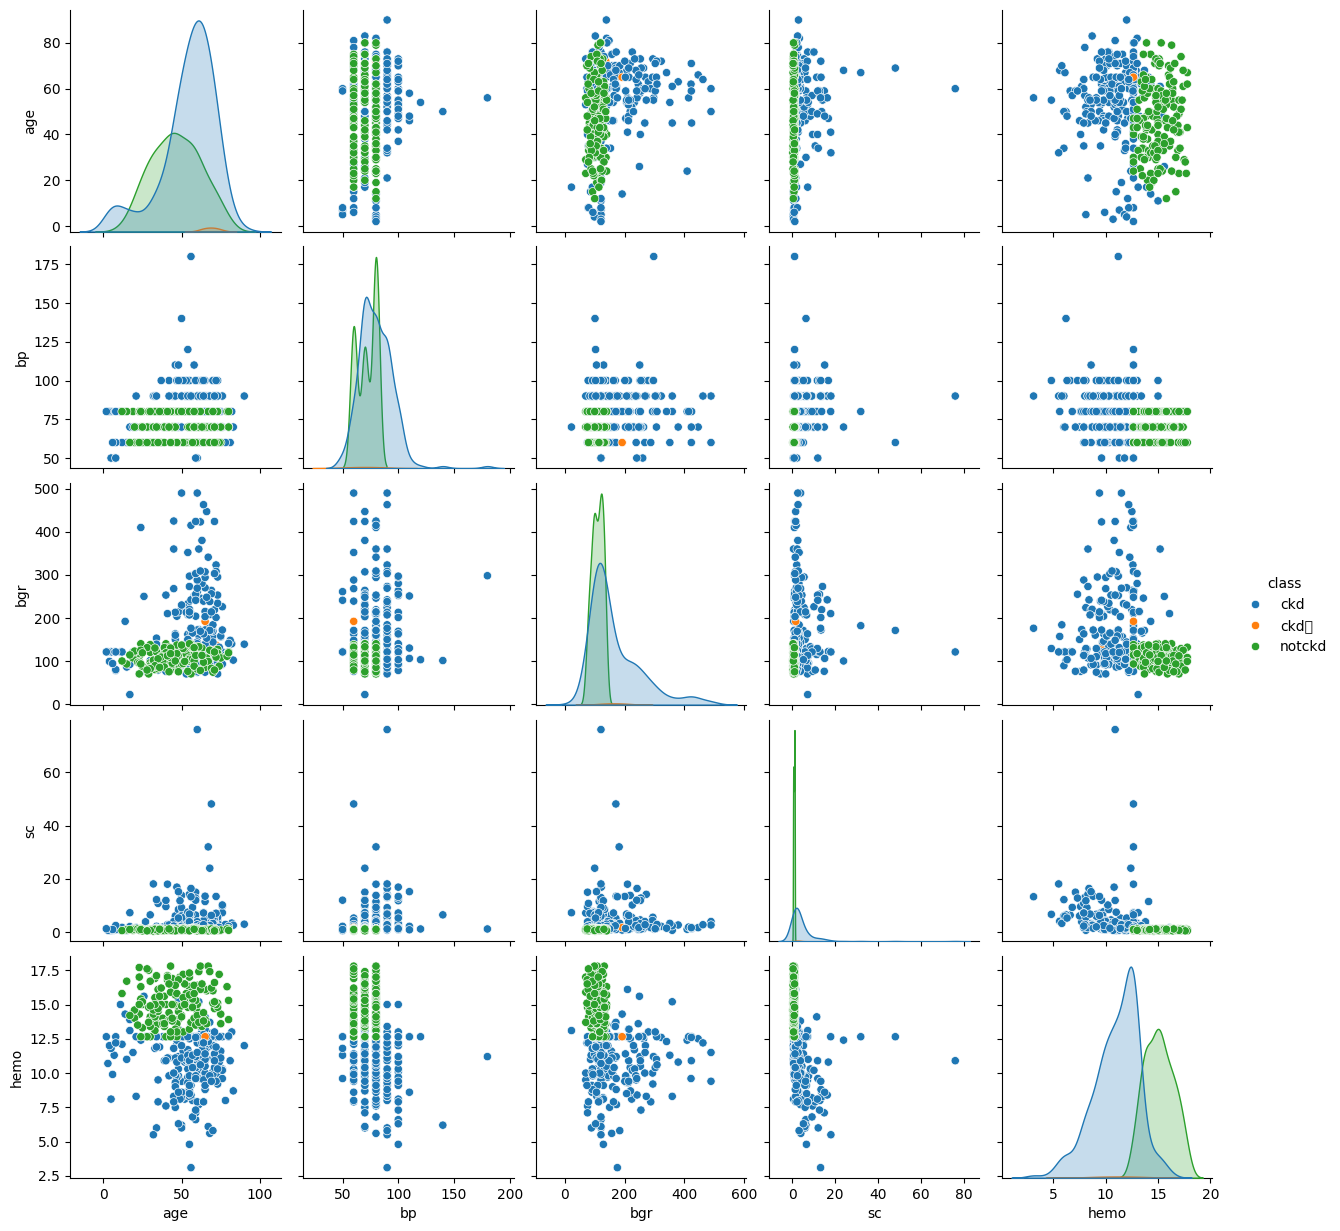

In [22]:
import seaborn as sns

sns.pairplot(df[["age", "bp", "bgr", "sc", "hemo", "class"]], hue="class")

Було побудовано матрицю парних графіків pairplot, яка дозволяє одночасно проаналізувати залежності між кількома числовими ознаками датасету, такими як вік (age), артеріальний тиск (bp), рівень глюкози (bgr) та іншими показниками.
На діагоналі відображено розподіл кожної змінної, а поза діагоналлю — діаграми розсіювання для кожної пари ознак. Для кращої інтерпретації я використала кольорове кодування за класами (є або нема хронічної хвороби нирок).
З графіка видно, що деякі ознаки мають різний розподіл для різних класів. Зокрема, рівень глюкози (bgr) та інші показники демонструють відмінності між групами пацієнтів, що може свідчити про їхню важливість для класифікації.
Також можна помітити, що для більшості пар змінних не спостерігається чіткої лінійної залежності, однак окремі групування точок вказують на наявність певних закономірностей.